# 5 · Choropleth, shapes & map decoration

`choropleth` / `shapes` for vector polygons, plus named domains and coastlines / borders / basemap. The polygons here are the DEM's own cells, vectorised by pyramids and coloured by elevation. Network-dependent overlays are wrapped so the notebook always renders.

In [1]:
%matplotlib inline
from pathlib import Path

# Resolve the repo root so the bundled sample DEM is found whether this runs from
# docs/examples/ (mkdocs) or the repository root.
ROOT = Path.cwd()
while not (ROOT / "examples" / "data" / "LisbonElevation.tif").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DEM = str(ROOT / "examples" / "data" / "LisbonElevation.tif")
print("DEM:", DEM)

DEM: C:\gdrive\algorithms\Visualization\Digital-Earth\examples\data\LisbonElevation.tif


In [2]:
import numpy as np
from pyramids.dataset import Dataset
from digitalearth.scene import Map

ds = Dataset.read_file(DEM)
coarse = ds.resample(ds.cell_size * 12)   # coarse cells -> polygon features
# vectorise the cells (pyramids) and attach the per-cell elevation as the value column
cells = coarse.get_cell_polygons()
cells['elevation'] = coarse.read_array(band=0).astype('float64').ravel()
print('polygons:', len(cells))

2026-05-28 19:42:45 | INFO | pyramids.base.config | Logging is configured.


polygons: 1610


## choropleth — polygons coloured by elevation

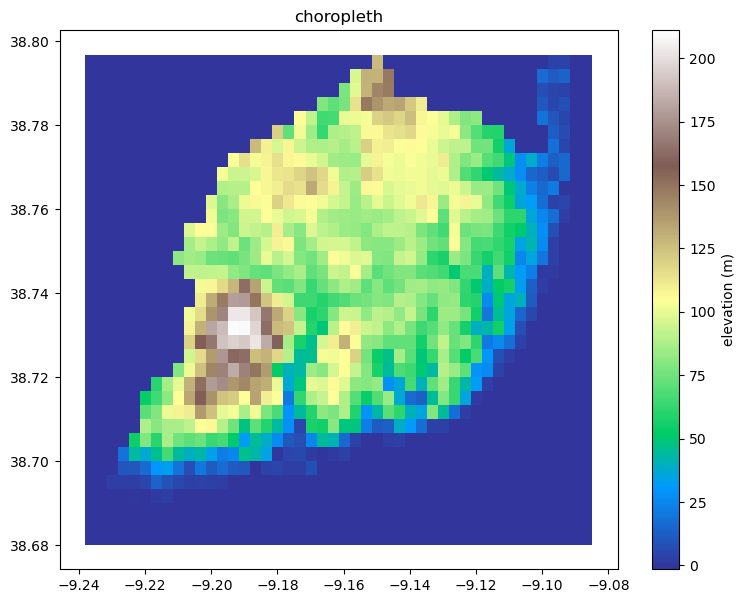

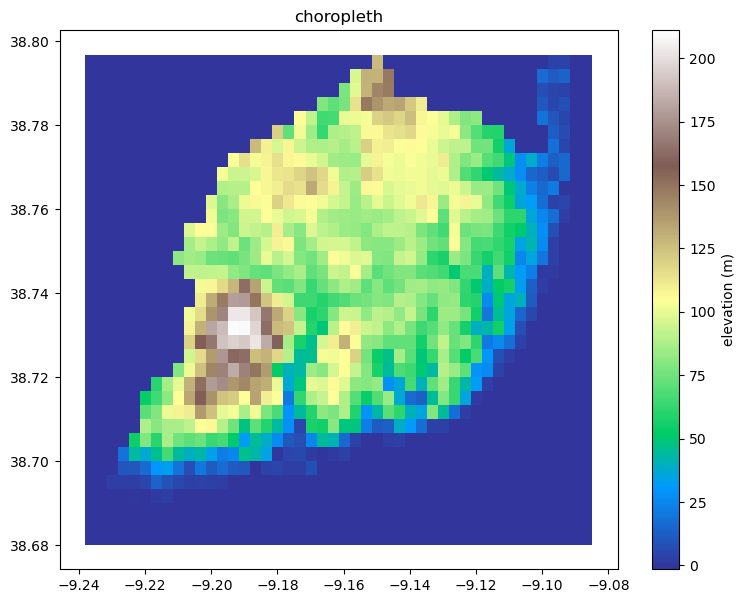

In [3]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.choropleth(cells, column='elevation', cmap='terrain')
m.colorbar(label='elevation (m)')
m.set_title('choropleth')
m.fig

## shapes — outlines only

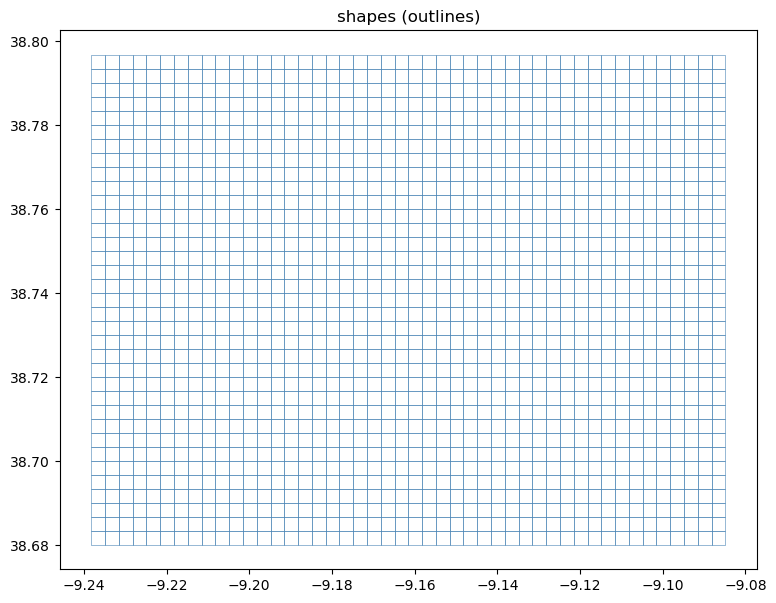

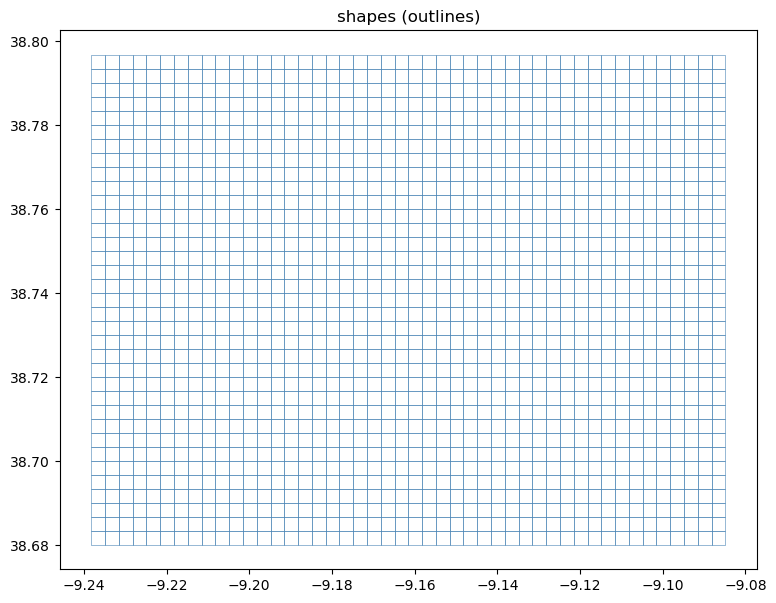

In [4]:
m = Map(crs=coarse.epsg, figsize=(9, 7))
m.shapes(cells, edgecolor='steelblue', linewidth=0.4)
m.set_title('shapes (outlines)')
m.fig

## Named domains (extent from a region, reprojected via pyramids)

xlim: [-2782987, 5009377]


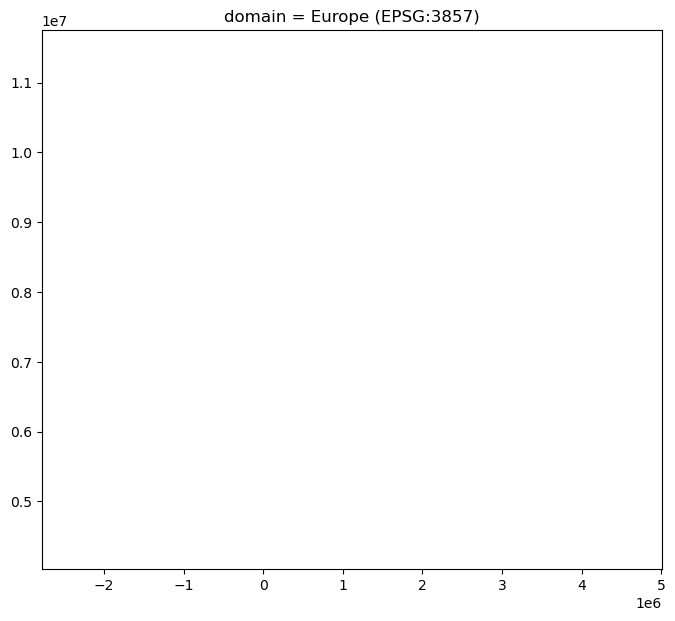

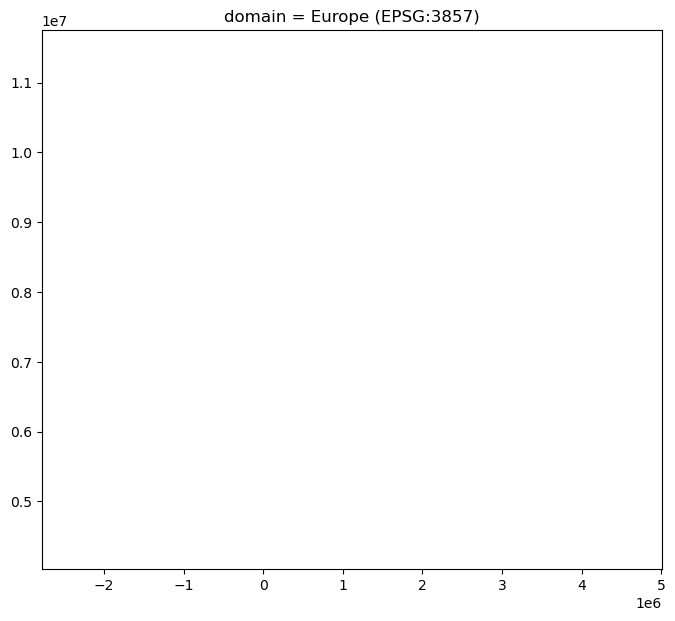

In [5]:
m = Map(crs=3857, figsize=(8, 7))
m.set_domain('europe')
print('xlim:', [round(float(v)) for v in m.ax.get_xlim()])
m.set_title('domain = Europe (EPSG:3857)')
m.fig

## DEM + coastlines / borders (need network — guarded)

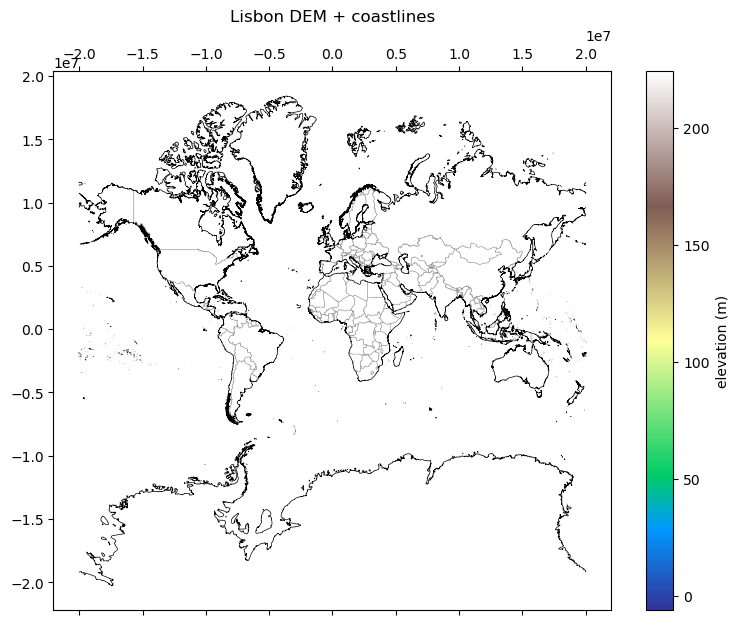

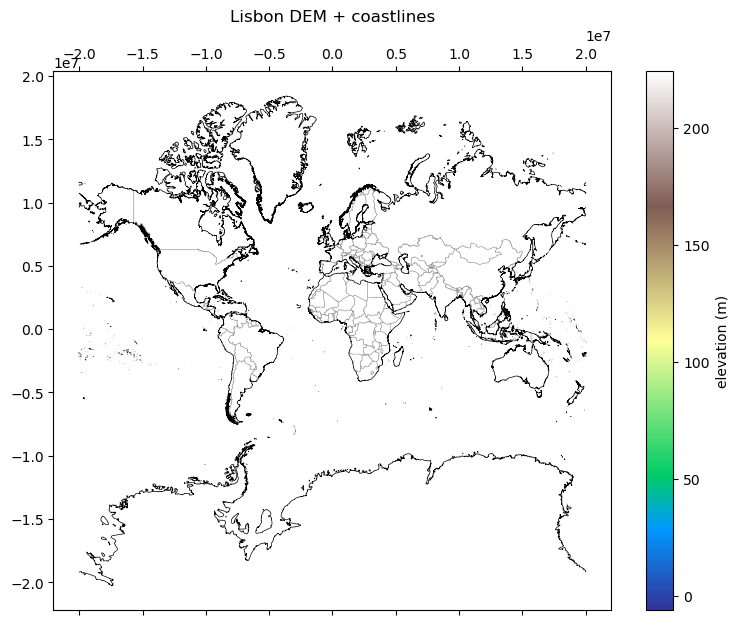

In [6]:
m = Map(crs=3857, figsize=(9, 7))
m.imshow(ds, cmap='terrain')
for name in ('coastlines', 'borders'):
    try:
        getattr(m, name)(resolution='10m')
    except Exception as exc:
        print(f'{name}: unavailable offline ({type(exc).__name__})')
m.colorbar(label='elevation (m)')
m.set_title('Lisbon DEM + coastlines')
m.fig